# 003_retention_analysis
├── load_and_prepare_data()

├── create_starting_location_df()

├── run_analysis()

├── make_plots()

├── summarize_all_results()

└── main()

In [85]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils import hypotheses, locations, extents
import os
# --- Config ---
DATA_DIR = Path('/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/')
FIG_DIR = Path('/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures')

PRESENCE_COLS = ['BS', 'GERL', 'GP', 'MB2', 'outside']
CRITICAL_COLS = ['larval_id', 'date', 'lon', 'lat', 'hypothesis', 'start_year', 'IDL_loc', 'stage']

FILES = {
    'raw': DATA_DIR / 'processed_trajectories_wpresence_unfiltered.csv',
    'filtered': DATA_DIR / 'processed_trajectories_21dfilter.csv'
}

In [86]:
# --- Helper: Get T==0 starting locations ---
def extract_starting_locations(df):
    """Return DataFrame of larval starting locations (T==0) with renamed columns."""
    t0 = df[df['T'] == 0].copy()
    cols = CRITICAL_COLS + PRESENCE_COLS
    t0 = t0[cols].copy()
    return t0.rename(columns={'date': 'release_date', 'lat': 'release_lat', 'lon': 'release_lon'})

# --- Load both datasets ---
datasets = {}
starting_locations = {}

for key, path in FILES.items():
    df = pd.read_csv(path)
    print(f"{key.upper()} dataset: {df.larval_id.nunique()} unique larvae")
    datasets[key] = df
    starting_locations[key] = extract_starting_locations(df)

# --- Example: merge definitive IDL_loc into full data ---
def merge_definitive_idl(df, starting_df):
    """Merge in consistent IDL_loc assignment from starting_df."""
    merged = pd.merge(
        df,
        starting_df[['larval_id', 'hypothesis', 'start_year', 'IDL_loc']],
        on=['larval_id', 'hypothesis', 'start_year'],
        how='inner',
        suffixes=('', '_assigned')
    )
    merged['IDL_loc'] = merged['IDL_loc_assigned']
    merged.drop(columns=['IDL_loc_assigned'], inplace=True)
    return merged

RAW dataset: 16658 unique larvae
FILTERED dataset: 11487 unique larvae


In [87]:
# Run it:
# Example use
merged_raw = merge_definitive_idl(datasets['raw'], starting_locations['raw'])
merged_filtered = merge_definitive_idl(datasets['filtered'], starting_locations['filtered'])

print(f"✅ Merged RAW: {merged_raw.larval_id.nunique()} larvae retained")
print(f"✅ Merged FILTERED: {merged_filtered.larval_id.nunique()} larvae retained")

✅ Merged RAW: 16658 larvae retained
✅ Merged FILTERED: 11487 larvae retained


In [88]:
def summarize_larvae_by_nursery(df, hypothesis, label=None):
    """
    Print and return a summary of larval counts per nursery and year for a given hypothesis.
    
    Args:
        df (pd.DataFrame): Merged trajectory data with definitive IDL_loc
        hypothesis (str): Hypothesis string (e.g., 'h_dvm')
        label (str): Optional dataset label to include in the print header
    """
    subset = df[df['hypothesis'] == hypothesis]
    summary = (
        subset.groupby(['IDL_loc', 'start_year'])['larval_id']
        .nunique()
        .reset_index(name='n_larvae')
        .sort_values(['IDL_loc', 'start_year'])
    )

    label_str = f" [{label}]" if label else ""
    print(f"\n🔎 Larval counts for hypothesis '{hypothesis}'{label_str}:\n")
    print(summary.to_string(index=False))
    return summary

In [89]:
# Run gut check summaries
gutcheck_results = {}

for label, df in {'raw': merged_raw, 'filtered': merged_filtered}.items():
    for hypothesis in ['h_dvm', 'h_size']:
        key = f"{label}_{hypothesis}"
        gutcheck_results[key] = summarize_larvae_by_nursery(df, hypothesis, label=label)


🔎 Larval counts for hypothesis 'h_dvm' [raw]:

IDL_loc  start_year  n_larvae
     BS        2016       366
     BS        2017       263
     BS        2018       320
   GERL        2016       107
   GERL        2017        72
   GERL        2018       108
     GP        2016       141
     GP        2017        52
     GP        2018        58
    MB2        2016        91
    MB2        2017        88
    MB2        2018        47

🔎 Larval counts for hypothesis 'h_size' [raw]:

IDL_loc  start_year  n_larvae
     BS        2016      1213
     BS        2017      1056
     BS        2018      1304
   GERL        2016       561
   GERL        2017       494
   GERL        2018       668
     GP        2016      1484
     GP        2017      1217
     GP        2018      1164
    MB2        2016      1287
    MB2        2017      1150
    MB2        2018      1075

🔎 Larval counts for hypothesis 'h_dvm' [filtered]:

IDL_loc  start_year  n_larvae
     BS        2016       290
     BS   

### Process Retention
    1.	Group by larval_id, IDL_loc
	2.	Count number of True days
	3.	Assign that count as the retention days for that larva in that nursery

In [90]:
def summarize_retention_days_per_larva(df, id_col='larval_id'):
    """
    Calculate how many days each larva was retained in its assigned nursery (IDL_loc).
    
    For each larva, this:
    - Uses its assigned IDL_loc (nursery)
    - Looks up that nursery's Boolean presence column
    - Sums True values (i.e., days present in that box)
    
    Returns:
        DataFrame with one row per larva:
        [larval_id, start_year, hypothesis, IDL_loc, Retention_Days, Season]
    """
    records = []

    for loc in locations:
        # Subset to larvae assigned to this location
        df_loc = df[df['IDL_loc'] == loc]

        if loc not in df_loc.columns:
            print(f"Warning: location column '{loc}' not found in DataFrame — skipping.")
            continue

        # Ensure boolean column is numeric (True → 1, False → 0)
        if df_loc[loc].dtype == bool:
            df_loc = df_loc.copy()
            df_loc[loc] = df_loc[loc].astype(int)

        # Group by larva to sum retention days in their assigned box
        grouped = (
            df_loc.groupby([id_col, 'start_year', 'hypothesis', 'IDL_loc'])[loc]
            .sum()
            .reset_index()
            .rename(columns={loc: 'Retention_Days'})
        )

        # Add season label
        grouped['Season'] = grouped['start_year'].apply(lambda x: f"{x}–{x + 1}")
        records.append(grouped)

    return pd.concat(records, ignore_index=True)

In [91]:
# --- Extract retention data for raw and filtered datasets ---
retention_summary = {
    label: summarize_retention_days_per_larva(df)
    for label, df in {'raw': merged_raw, 'filtered': merged_filtered}.items()
}

retention_summary['raw'].head()


,larval_id,start_year,hypothesis,IDL_loc,Retention_Days,Season
0,00_16_1_0001,2016,h_null,BS,0,2016–2017
1,00_16_1_0002,2016,h_null,BS,3,2016–2017
2,00_16_1_0003,2016,h_null,BS,93,2016–2017
3,00_16_1_0004,2016,h_null,BS,95,2016–2017
4,00_16_1_0005,2016,h_null,BS,75,2016–2017


In [92]:
# Preview
retention_summary['filtered'].head()

,larval_id,start_year,hypothesis,IDL_loc,Retention_Days,Season
0,00_16_1_0003,2016,h_null,BS,93,2016–2017
1,00_16_1_0004,2016,h_null,BS,95,2016–2017
2,00_16_1_0005,2016,h_null,BS,75,2016–2017
3,00_16_1_0006,2016,h_null,BS,170,2016–2017
4,00_16_1_0007,2016,h_null,BS,146,2016–2017


In [93]:
# Summarize
def summarize_retention_distribution(ret_df):
    """
    Generate summary statistics per [IDL_loc, start_year, hypothesis].
    
    Returns:
        A tidy DataFrame with:
        [IDL_loc, start_year, hypothesis, n, Mean ± SD, Median (IQR)]
    """
    grouped = (
        ret_df
        .groupby(['IDL_loc', 'start_year', 'hypothesis'])['Retention_Days']
        .describe()
        .round(2)
        .reset_index()
    )

    records = []
    for _, row in grouped.iterrows():
        mean = row['mean']
        std = row['std']
        q25 = row['25%']
        q50 = row['50%']
        q75 = row['75%']

        mean_sd = f"{mean:.1f}" if pd.isna(std) else f"{mean:.1f} ± {std:.1f}"
        iqr = f"{q50:.1f} ({q25:.1f}–{q75:.1f})"

        records.append({
            'Nursery': row['IDL_loc'],
            'Start Year': row['start_year'],
            'Hypothesis': row['hypothesis'],
            'n': int(row['count']),
            'Mean ± SD': mean_sd,
            'Median (IQR)': iqr
        })

    return pd.DataFrame.from_records(records)

In [94]:
# Apply to retention days per larva
retention_per_larva = {
    label: summarize_retention_days_per_larva(df)
    for label, df in {'raw': merged_raw, 'filtered': merged_filtered}.items()
}

# Generate summary tables
summary_by_dataset = {
    label: summarize_retention_distribution(df)
    for label, df in retention_per_larva.items()
}

In [95]:
summary_by_dataset['filtered'].head()


,Nursery,Start Year,Hypothesis,n,Mean ± SD,Median (IQR)
0,BS,2016,h_dvm,290,78.5 ± 43.4,69.0 (42.0–105.8)
1,BS,2016,h_ice,169,85.3 ± 48.2,74.0 (43.0–125.0)
2,BS,2016,h_null,179,84.1 ± 45.2,79.0 (46.5–115.5)
3,BS,2016,h_size,891,74.6 ± 41.1,64.0 (40.0–101.0)
4,BS,2017,h_dvm,184,78.4 ± 42.6,68.5 (45.8–102.2)


In [96]:
from pathlib import Path

def export_summary_tables(summary_dict, output_dir, base_filename):
    """
    Save summary tables (raw and filtered) as CSV and LaTeX.
    
    Args:
        summary_dict (dict): Dictionary like {'raw': df, 'filtered': df}
        output_dir (str or Path): Directory to save files in
        base_filename (str): Common prefix for output files
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for label, df in summary_dict.items():
        csv_path = output_dir / f"{base_filename}_{label}.csv"
        tex_path = output_dir / f"{base_filename}_{label}.tex"

        df.to_csv(csv_path, index=False)
        df.to_latex(tex_path, index=False, escape=False)
        print(f"✅ Exported {label} summary: \n  CSV:  {csv_path}\n  LaTeX: {tex_path}")

In [97]:
export_summary_tables(
    summary_dict=summary_by_dataset,
    output_dir='processed_data/summary_outputs',
    base_filename='retention_summary'
)

✅ Exported raw summary: 
  CSV:  processed_data/summary_outputs/retention_summary_raw.csv
  LaTeX: processed_data/summary_outputs/retention_summary_raw.tex
✅ Exported filtered summary: 
  CSV:  processed_data/summary_outputs/retention_summary_filtered.csv
  LaTeX: processed_data/summary_outputs/retention_summary_filtered.tex


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_87864/1847106805.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  df.to_latex(tex_path, index=False, escape=False)


# Plot and Visualize

In [98]:
print(retention_per_larva.keys())

df_raw = retention_per_larva['raw']
df_filtered = retention_per_larva['filtered']

# Filter to only h_dvm and h_size
df_raw = df_raw[df_raw['hypothesis'].isin(['h_dvm', 'h_size'])]
df_filtered = df_filtered[df_filtered['hypothesis'].isin(['h_dvm', 'h_size'])]

dict_keys(['raw', 'filtered'])


In [99]:
import utils
# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

locations = utils.locations

location_labels = {key: value['name'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

from string import ascii_uppercase
import seaborn as sns

In [100]:
hypothesis_labels

{'h_null': 'Ocean Only', 'h_ice': 'Sea Ice', 'h_dvm': '620', 'h_size': '640'}

In [101]:
def plot_retention_violin_comparison(retention_df, hypotheses, save_path=None, filtered=False):
    """
    Create a 4x2 grid of violin plots showing larval retention time distributions
    across nurseries and hypotheses, grouped by season.
    
    Args:
        retention_df (pd.DataFrame): retention-per-larva DataFrame
        hypotheses (list): list of 2 hypothesis names (e.g., ['h_dvm', 'h_size'])
        save_path (str or Path): directory to save output figure (optional)
        filtered (bool): whether the data is 21d-filtered (affects filename)
    """
    # Set up subplots: 4 nurseries x 2 hypotheses
    fig, axes = plt.subplots(4, 2, figsize=(10, 13), sharex=True, sharey=True)

    # Sort nursery layout
    ordered_locations = sorted(locations.keys(), key=lambda x: location_order[x])

    # Annotation label iterator
    panel_labels = iter(ascii_uppercase)

    for col, hypothesis in enumerate(hypotheses):
        for row, location in enumerate(ordered_locations):
            ax = axes[row, col]

            # Filter data
            subset = retention_df[
                (retention_df['hypothesis'] == hypothesis) &
                (retention_df['IDL_loc'] == location)
            ]

            if subset.empty:
                ax.set_visible(False)
                continue

            sns.violinplot(
                data=subset,
                x='Season',
                y='Retention_Days',
                hue='start_year',
                palette={2016: '#648fff', 2017: '#dc267f', 2018: '#ffb000'},
                cut=0,
                linewidth=1,
                ax=ax
            )

            ax.axhline(y=21, color='black', linestyle='--', linewidth=0.5, alpha=0.8)

            # Add subplot annotation (A, B, C, ...)
            label = next(panel_labels)
            ax.text(
                0.98, 0.98, label,
                transform=ax.transAxes,
                fontsize=12, fontweight='bold',
                ha='right', va='top'
            )

            # Column title
            if row == 0:
                title = hypothesis_labels.get(hypothesis, hypothesis)
                ax.set_title(f'{title}$\\mu$m', fontsize=14)

            # Row label
            if col == 0:
                loc_label = location_labels.get(location, location)
                ax.set_ylabel(f'{loc_label}-NG\nRetention (days)', fontsize=12)
            else:
                ax.set_ylabel('')

            ax.set_xlabel('Season', fontsize=10)
            ax.tick_params(axis='x', labelsize=11)
            ax.set_axisbelow(True)
            ax.grid(True, linestyle='--', linewidth=0.75, color='lavender')

            if ax.get_legend():
                ax.get_legend().remove()
    
    # fig.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.tight_layout()

    if save_path:
        fname = f"Retention_{hypotheses[0]}_{hypotheses[1]}_comparison"
        if filtered:
            fname += "-FILTERED.png"
        else:
            fname += "-UNFILTERED.png"
        plt.savefig(os.path.join(save_path, fname), dpi=300, bbox_inches='tight')

    plt.show()

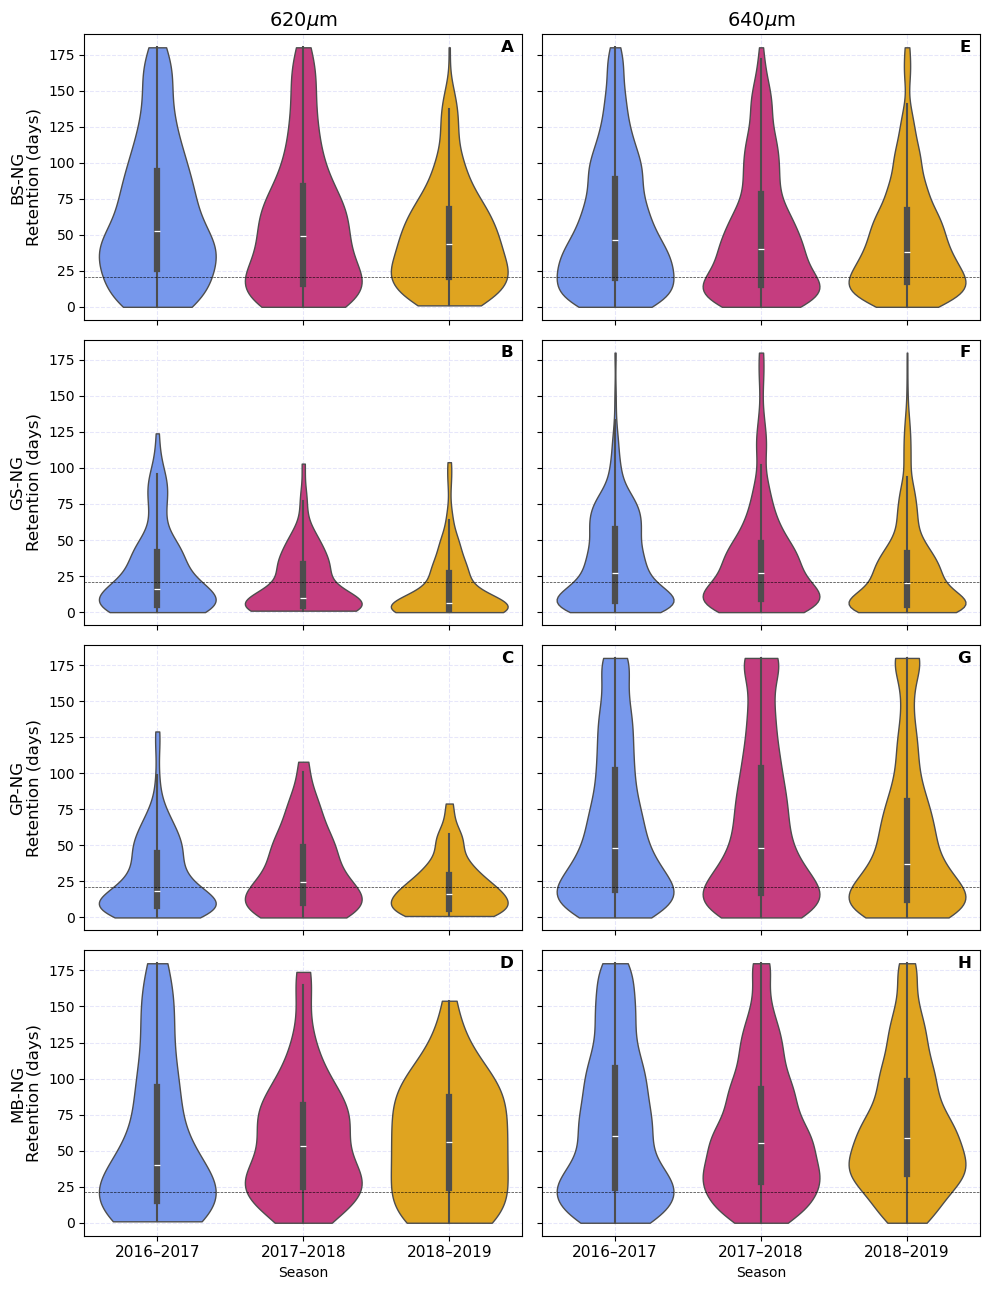

In [102]:
plot_retention_violin_comparison(
    retention_df=df_raw,
    hypotheses=['h_dvm', 'h_size'],
    save_path=FIG_DIR,
    filtered=False
)

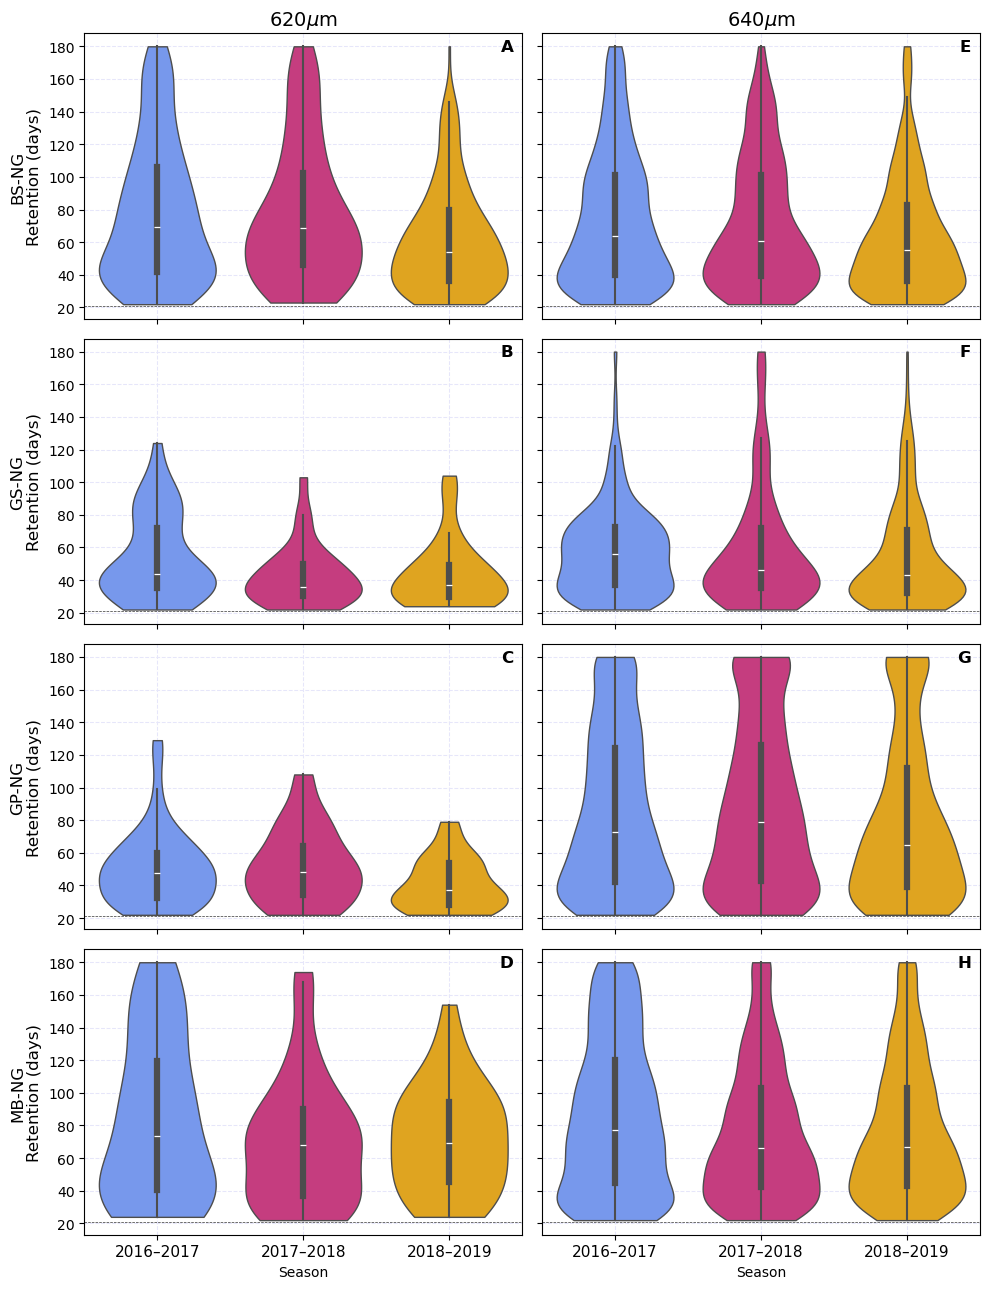

In [103]:
plot_retention_violin_comparison(
    retention_df=df_filtered,
    hypotheses=['h_dvm', 'h_size'],
    save_path=FIG_DIR,
    filtered=True
)

# Make Summary Stat Tables

In [104]:
def summarize_annual_violin_input(df):
    """
    Summarize annual larval retention statistics in formatted string form for display.

    For each combination of hypothesis, nursery ground (IDL_loc), and start year,
    this function calculates the following summary statistics on the 'Retention_Days' column:
    - Total count (n)
    - Mean ± standard deviation (formatted string)
    - Median and interquartile range (formatted string)
    - Minimum and maximum

    This is designed for use in tables or figure supplements where formatted strings
    (e.g., "45.3 ± 12.7") are preferred over numeric columns.

    Parameters:
        df (pd.DataFrame): DataFrame containing at least 'hypothesis', 'IDL_loc',
                           'start_year', and 'Retention_Days' columns.

    Returns:
        pd.DataFrame: One row per (hypothesis, IDL_loc, start_year), with columns:
            - hypothesis
            - NG (nursery ground)
            - start_year
            - n
            - mean ± std (str)
            - median (IQR) (str)
            - min
            - max
    """
    grouped = df.groupby(['hypothesis', 'IDL_loc', 'start_year'])
    records = []

    for (hypothesis, location, year), group in grouped:
        vals = group['Retention_Days'].dropna()
        n = len(vals)
        mean = vals.mean()
        std = vals.std()
        median = vals.median()
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        rmin = vals.min()
        rmax = vals.max()

        records.append({
            'hypothesis': hypothesis,
            'NG': location,
            'start_year': year,
            'n': n,
            'mean ± std': f"{mean:.1f} ± {std:.1f}",
            'median (IQR)': f"{median:.1f} ({iqr:.1f})"#,
            # 'min': rmin,
            # 'max': rmax
        })

    return pd.DataFrame(records)

In [105]:
def summarize_annual_violin_input_numeric(df):
    """
    Compute annual statistics (numeric form) for larval retention from raw retention_df input.
    
    Args:
        df (pd.DataFrame): DataFrame with 'Retention_Days', 'hypothesis', 'IDL_loc', and 'start_year'
    
    Returns:
        pd.DataFrame: One row per (hypothesis, IDL_loc, start_year) with numeric summary statistics
    """
    grouped = df.groupby(['hypothesis', 'IDL_loc', 'start_year'])
    records = []

    for (hypothesis, location, year), group in grouped:
        vals = group['Retention_Days'].dropna()
        n = len(vals)
        mean = vals.mean()
        std = vals.std()
        median = vals.median()
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        rmin = vals.min()
        rmax = vals.max()

        records.append({
            'hypothesis': hypothesis,
            'NG': location,
            'start_year': year,
            'n': n,
            'mean_days': mean,
            'std_days': std,
            'median_days': median,
            'iqr_days': iqr#,
            # 'min_days': rmin,
            # 'max_days': rmax
        })

    return pd.DataFrame(records)

In [106]:
# Annual numeric summaries for raw and filtered
df_raw_annual_num = summarize_annual_violin_input_numeric(df_raw)
df_filtered_annual_num = summarize_annual_violin_input_numeric(df_filtered)

# Merge and compute deltas
df_annual_delta = pd.merge(
    df_raw_annual_num,
    df_filtered_annual_num,
    on=['hypothesis', 'NG', 'start_year'],
    suffixes=('_raw', '_21d')
)

df_annual_delta['Δ n'] = df_annual_delta['n_raw'] - df_annual_delta['n_21d']
df_annual_delta['percent filtered out'] = (df_annual_delta['Δ n'] / df_annual_delta['n_raw'] * 100).round(1)
df_annual_delta['Δ mean days'] = (df_annual_delta['mean_days_raw'] - df_annual_delta['mean_days_21d']).round(1)
df_annual_delta['Δ median days'] = (df_annual_delta['median_days_raw'] - df_annual_delta['median_days_21d']).round(1)

In [107]:
df_annual_delta

,hypothesis,NG,start_year,n_raw,mean_days_raw,std_days_raw,median_days_raw,iqr_days_raw,n_21d,mean_days_21d,std_days_21d,median_days_21d,iqr_days_21d,Δ n,percent filtered out,Δ mean days,Δ median days
0,h_dvm,BS,2016,366,63.882514,48.092660,52.5,68.00,290,78.462069,43.386175,69.0,63.75,76,20.8,-14.6,-16.5
1,h_dvm,BS,2017,263,57.733840,47.724614,49.0,67.50,184,78.413043,42.598944,68.5,56.50,79,30.0,-20.7,-19.5
2,h_dvm,BS,2018,320,48.834375,35.841703,43.5,47.25,237,62.097046,32.267602,54.0,44.00,83,25.9,-13.3,-10.5
3,h_dvm,GERL,2016,107,27.588785,28.925393,16.0,37.00,45,54.511111,26.159148,44.0,37.00,62,57.9,-26.9,-28.0
4,h_dvm,GERL,2017,72,20.819444,22.091568,10.0,29.25,29,43.137931,18.602466,36.0,20.00,43,59.7,-22.3,-26.0
5,h_dvm,GERL,2018,108,16.675926,21.738819,6.0,25.00,32,44.343750,20.892365,37.0,19.25,76,70.4,-27.7,-31.0
6,h_dvm,GP,2016,141,28.524823,26.866490,18.0,37.00,66,51.030303,23.537185,47.5,27.50,75,53.2,-22.5,-29.5
7,h_dvm,GP,2017,52,32.596154,27.949015,24.5,39.25,28,52.714286,23.161042,48.5,30.25,24,46.2,-20.1,-24.0
8,h_dvm,GP,2018,58,21.431034,18.975619,16.5,23.75,22,41.045455,16.007371,37.0,25.50,36,62.1,-19.6,-20.5
9,h_dvm,MB2,2016,91,59.010989,53.320518,40.0,79.50,60,84.083333,49.435214,73.5,78.50,31,34.1,-25.1,-33.5


# INCLUDE Local vs Import

Function add_transition_columns
•	For each location:
	•	Adds a prev column with the previous timestep’s presence (True/False).
	•	Assigns a transition string (initial_inside, immigrate, emigrate, inside, outside) using a helperm

In [108]:
def add_transition_columns(df, locations):
    """
    Add transition and origin classification columns for each nursery location.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with boolean nursery columns (e.g., ['BS', 'GERL']).
        locations (list): List of nursery location keys (e.g., ['BS', 'GERL', 'GP', 'MB2']).
    
    Returns:
        pd.DataFrame: Updated DataFrame with transition and origin info.
    """
    def categorize_transition(prev, curr):
        if pd.isna(prev):
            return 'initial_inside' if curr else 'initial_outside'
        if not prev and curr:
            return 'immigrate'
        elif prev and not curr:
            return 'emigrate'
        elif prev and curr:
            return 'inside'
        else:
            return 'outside'

    for loc in locations:
        prev_col = f'{loc}_prev'
        trans_col = f'{loc}_transition'
        origin_col = f'{loc}_origin'

        # Step 1: Add previous-state and transition column
        df[prev_col] = df.groupby('larval_id')[loc].shift(1)
        df[trans_col] = [categorize_transition(p, c) for p, c in zip(df[prev_col], df[loc])]

        # Step 2: Determine origin (Local vs Immigrant) at larval level
        # Get larval_ids with 'initial_inside' at this location
        local_ids = (
            df[df[trans_col] == 'initial_inside']
            .groupby('larval_id')
            .size()
            .index
        )
        
        # Map back to DataFrame
        df[origin_col] = df['larval_id'].apply(lambda x: 'Local' if x in local_ids else 'Immigrant')

    return df

In [109]:
# Add transition columns to the dataframe
merged_raw = add_transition_columns(merged_raw, locations)
merged_filtered = add_transition_columns(merged_filtered, locations)


In [110]:
def nursery_origin_summary_numeric(df, nurseries, hypothesis):
    """
    Compute annual origin statistics (Local vs Immigrant) for larvae in each nursery.

    Parameters:
        df (pd.DataFrame): DataFrame with 'IDL_loc', 'start_year', and '{nursery}_origin' columns.
        nurseries (list): List of nursery ground keys (e.g., ['BS', 'GERL', 'GP', 'MB2']).
        hypothesis (str): Hypothesis to filter by (e.g., 'h_dvm').

    Returns:
        pd.DataFrame: Summary with numeric origin stats:
            - n: total larvae retained
            - spawn_local: # classified as local
            - spawn_external: # classified as immigrant
            - percent_local: percent local
            - NG, start_year, hypothesis
    """
    records = []
    df_hyp = df[df['hypothesis'] == hypothesis]

    for nursery in nurseries:
        origin_col = f"{nursery}_origin"

        # Filter to larvae that stayed in this nursery
        df_ng = df_hyp[df_hyp['IDL_loc'] == nursery]

        for year in sorted(df_ng['start_year'].unique()):
            df_year = df_ng[df_ng['start_year'] == year].drop_duplicates(subset='larval_id')

            total = len(df_year)
            local = (df_year[origin_col] == 'Local').sum()
            immigrant = (df_year[origin_col] == 'Immigrant').sum()
            percent_local = (local / total * 100) if total > 0 else 0.0

            records.append({
                'hypothesis': hypothesis,
                'NG': nursery,
                'start_year': year,
                'n': total,
                'spawn_local': local,
                'spawn_external': immigrant,
                'percent_local': round(percent_local, 1),
            })

    return pd.DataFrame(records)

In [111]:
def nursery_origin_counts(df, nurseries, hypothesis, label):
    """
    Validate larval counts per nursery and year by origin type.
    Includes a 'label' column to distinguish raw vs filtered.

    Returns a DataFrame showing:
    - total larvae that used the nursery
    - number of locals
    - number of immigrants
    - whether local + immigrant == total
    - hypothesis name
    - label (e.g., 'raw' or 'filtered')
    """
    records = []
    df_hyp = df[df['hypothesis'] == hypothesis]

    for nursery in nurseries:
        origin_col = f"{nursery}_origin"

        # Only include larvae definitively assigned to this nursery
        df_ng = df_hyp[df_hyp['IDL_loc'] == nursery]

        for year in sorted(df_ng['start_year'].unique()):
            df_year = df_ng[df_ng['start_year'] == year]

            # Avoid duplicate larval_ids
            df_year_unique = df_year.drop_duplicates(subset='larval_id')

            local_ids = df_year_unique[df_year_unique[origin_col] == 'Local']['larval_id']
            immigrant_ids = df_year_unique[df_year_unique[origin_col] == 'Immigrant']['larval_id']

            total = len(df_year_unique)
            locals_ = len(local_ids)
            immigrants = len(immigrant_ids)
            match = (locals_ + immigrants == total)

            records.append({
                'label': label,
                'hypothesis': hypothesis,
                'NG': nursery,
                'start_year': year,
                'total_larvae': total,
                'spawn_local': locals_,
                'spawn_external': immigrants,
                'match': match
            })

    return pd.DataFrame(records)

In [112]:
# Define both hypotheses and nurseries
hypotheses = ['h_dvm', 'h_size']
nurseries = ['BS', 'GERL', 'GP', 'MB2']

# Run for raw and filtered, both hypotheses
origin_raw_all = pd.concat([
    nursery_origin_summary_numeric(merged_raw, nurseries, hypothesis=hyp)
    for hyp in hypotheses
], ignore_index=True)

origin_filtered_all = pd.concat([
    nursery_origin_summary_numeric(merged_filtered, nurseries, hypothesis=hyp)
    for hyp in hypotheses
], ignore_index=True)

# Merge raw and filtered summaries
origin_annual_delta = pd.merge(
    origin_raw_all,
    origin_filtered_all,
    on=['hypothesis', 'NG', 'start_year'],
    suffixes=('_raw', '_21d')
)

# Compute deltas
origin_annual_delta['Δ n'] = origin_annual_delta['n_raw'] - origin_annual_delta['n_21d']
origin_annual_delta['Δ spawn_local'] = origin_annual_delta['spawn_local_raw'] - origin_annual_delta['spawn_local_21d']
origin_annual_delta['Δ spawn_external'] = origin_annual_delta['spawn_external_raw'] - origin_annual_delta['spawn_external_21d']
origin_annual_delta['Δ percent_local'] = (origin_annual_delta['percent_local_raw'] - origin_annual_delta['percent_local_21d']).round(1)

In [113]:
origin_annual_delta

,hypothesis,NG,start_year,n_raw,spawn_local_raw,spawn_external_raw,percent_local_raw,n_21d,spawn_local_21d,spawn_external_21d,percent_local_21d,Δ n,Δ spawn_local,Δ spawn_external,Δ percent_local
0,h_dvm,BS,2016,366,137,229,37.4,290,128,162,44.1,76,9,67,-6.7
1,h_dvm,BS,2017,263,144,119,54.8,184,123,61,66.8,79,21,58,-12.0
2,h_dvm,BS,2018,320,142,178,44.4,237,120,117,50.6,83,22,61,-6.2
3,h_dvm,GERL,2016,107,0,107,0.0,45,0,45,0.0,62,0,62,0.0
4,h_dvm,GERL,2017,72,0,72,0.0,29,0,29,0.0,43,0,43,0.0
5,h_dvm,GERL,2018,108,0,108,0.0,32,0,32,0.0,76,0,76,0.0
6,h_dvm,GP,2016,141,0,141,0.0,66,0,66,0.0,75,0,75,0.0
7,h_dvm,GP,2017,52,0,52,0.0,28,0,28,0.0,24,0,24,0.0
8,h_dvm,GP,2018,58,0,58,0.0,22,0,22,0.0,36,0,36,0.0
9,h_dvm,MB2,2016,91,47,44,51.6,60,38,22,63.3,31,9,22,-11.7


### Merge it all

In [114]:
# Merge without renaming since n_raw and n_21d are shared and equivalent
df_combined_annual_summary = pd.merge(
    df_annual_delta,
    origin_annual_delta.drop(columns=['n_raw', 'n_21d']),  # Avoid duplicate columns
    on=['hypothesis', 'NG', 'start_year'],
    how='outer'
)
df_combined_annual_summary

,hypothesis,NG,start_year,n_raw,mean_days_raw,std_days_raw,median_days_raw,iqr_days_raw,n_21d,mean_days_21d,...,spawn_local_raw,spawn_external_raw,percent_local_raw,spawn_local_21d,spawn_external_21d,percent_local_21d,Δ n_y,Δ spawn_local,Δ spawn_external,Δ percent_local
0,h_dvm,BS,2016,366,63.882514,48.092660,52.5,68.00,290,78.462069,...,137,229,37.4,128,162,44.1,76,9,67,-6.7
1,h_dvm,BS,2017,263,57.733840,47.724614,49.0,67.50,184,78.413043,...,144,119,54.8,123,61,66.8,79,21,58,-12.0
2,h_dvm,BS,2018,320,48.834375,35.841703,43.5,47.25,237,62.097046,...,142,178,44.4,120,117,50.6,83,22,61,-6.2
3,h_dvm,GERL,2016,107,27.588785,28.925393,16.0,37.00,45,54.511111,...,0,107,0.0,0,45,0.0,62,0,62,0.0
4,h_dvm,GERL,2017,72,20.819444,22.091568,10.0,29.25,29,43.137931,...,0,72,0.0,0,29,0.0,43,0,43,0.0
5,h_dvm,GERL,2018,108,16.675926,21.738819,6.0,25.00,32,44.343750,...,0,108,0.0,0,32,0.0,76,0,76,0.0
6,h_dvm,GP,2016,141,28.524823,26.866490,18.0,37.00,66,51.030303,...,0,141,0.0,0,66,0.0,75,0,75,0.0
7,h_dvm,GP,2017,52,32.596154,27.949015,24.5,39.25,28,52.714286,...,0,52,0.0,0,28,0.0,24,0,24,0.0
8,h_dvm,GP,2018,58,21.431034,18.975619,16.5,23.75,22,41.045455,...,0,58,0.0,0,22,0.0,36,0,36,0.0
9,h_dvm,MB2,2016,91,59.010989,53.320518,40.0,79.50,60,84.083333,...,47,44,51.6,38,22,63.3,31,9,22,-11.7


In [115]:
df_combined_annual_summary.columns

Index(['hypothesis', 'NG', 'start_year', 'n_raw', 'mean_days_raw',
       'std_days_raw', 'median_days_raw', 'iqr_days_raw', 'n_21d',
       'mean_days_21d', 'std_days_21d', 'median_days_21d', 'iqr_days_21d',
       'Δ n_x', 'percent filtered out', 'Δ mean days', 'Δ median days',
       'spawn_local_raw', 'spawn_external_raw', 'percent_local_raw',
       'spawn_local_21d', 'spawn_external_21d', 'percent_local_21d', 'Δ n_y',
       'Δ spawn_local', 'Δ spawn_external', 'Δ percent_local'],
      dtype='object')

In [116]:
# Desired final column order
final_order =  [
    'hypothesis', 'NG', 'start_year', 'n_raw', 'n_21d', 'percent filtered out',
    'percent_local_raw', 'percent_local_21d', 'Δ % local',
    'mean_days_raw', 'mean_days_21d', 'std_days_raw', 'std_days_21d',
    'median_days_raw', 'median_days_21d', 'iqr_days_raw', 'iqr_days_21d'
]

# Apply ordering, retaining only those that exist in the DataFrame
df_combined_annual_summary = df_combined_annual_summary[
    [col for col in final_order if col in df_combined_annual_summary.columns]
]
df_combined_annual_summary

,hypothesis,NG,start_year,n_raw,n_21d,percent filtered out,percent_local_raw,percent_local_21d,mean_days_raw,mean_days_21d,std_days_raw,std_days_21d,median_days_raw,median_days_21d,iqr_days_raw,iqr_days_21d
0,h_dvm,BS,2016,366,290,20.8,37.4,44.1,63.882514,78.462069,48.092660,43.386175,52.5,69.0,68.00,63.75
1,h_dvm,BS,2017,263,184,30.0,54.8,66.8,57.733840,78.413043,47.724614,42.598944,49.0,68.5,67.50,56.50
2,h_dvm,BS,2018,320,237,25.9,44.4,50.6,48.834375,62.097046,35.841703,32.267602,43.5,54.0,47.25,44.00
3,h_dvm,GERL,2016,107,45,57.9,0.0,0.0,27.588785,54.511111,28.925393,26.159148,16.0,44.0,37.00,37.00
4,h_dvm,GERL,2017,72,29,59.7,0.0,0.0,20.819444,43.137931,22.091568,18.602466,10.0,36.0,29.25,20.00
5,h_dvm,GERL,2018,108,32,70.4,0.0,0.0,16.675926,44.343750,21.738819,20.892365,6.0,37.0,25.00,19.25
6,h_dvm,GP,2016,141,66,53.2,0.0,0.0,28.524823,51.030303,26.866490,23.537185,18.0,47.5,37.00,27.50
7,h_dvm,GP,2017,52,28,46.2,0.0,0.0,32.596154,52.714286,27.949015,23.161042,24.5,48.5,39.25,30.25
8,h_dvm,GP,2018,58,22,62.1,0.0,0.0,21.431034,41.045455,18.975619,16.007371,16.5,37.0,23.75,25.50
9,h_dvm,MB2,2016,91,60,34.1,51.6,63.3,59.010989,84.083333,53.320518,49.435214,40.0,73.5,79.50,78.50


In [117]:
def summarize_3yr_average_combined(df_annual):
    """
    Compute 3-year average summary statistics from annual combined summary DataFrame.
    
    Parameters:
        df_annual (pd.DataFrame): Annual summary data with columns like:
            ['Hypothesis', 'NG', 'start_year', 'n_raw', 'n_21d', '% filtered out',
             'mean_days_raw', ..., 'percent_local_raw', ..., 'Δ % local']

    Returns:
        pd.DataFrame: Grouped 3-year average summary with mean values for all numeric columns.
    """
    # Drop start_year for averaging
    df_avg = (
        df_annual
        .drop(columns='start_year')
        .groupby(['hypothesis', 'NG'], as_index=False)
        .mean(numeric_only=True)
        .round(2)
    )
    return df_avg

df_3yr_average = summarize_3yr_average_combined(df_combined_annual_summary)
df_3yr_average

,hypothesis,NG,n_raw,n_21d,percent filtered out,percent_local_raw,percent_local_21d,mean_days_raw,mean_days_21d,std_days_raw,std_days_21d,median_days_raw,median_days_21d,iqr_days_raw,iqr_days_21d
0,h_dvm,BS,316.33,237.00,25.57,45.53,53.83,56.82,72.99,43.89,39.42,48.33,63.83,60.92,54.75
1,h_dvm,GERL,95.67,35.33,62.67,0.00,0.00,21.69,47.33,24.25,21.88,10.67,39.00,30.42,25.42
2,h_dvm,GP,83.67,38.67,53.83,0.00,0.00,27.52,48.26,24.60,20.90,19.67,44.33,33.33,27.75
3,h_dvm,MB2,75.33,55.67,25.60,60.07,64.40,58.41,75.61,45.24,40.52,49.83,70.17,66.67,60.17
4,h_size,BS,1191.00,833.33,30.13,33.07,34.70,52.13,70.16,42.54,38.61,41.33,60.00,60.67,56.42
5,h_size,GERL,574.33,299.00,47.53,21.40,26.00,33.94,57.38,33.91,31.61,24.67,48.33,41.75,37.17
6,h_size,GP,1288.33,895.33,30.73,26.20,33.83,61.66,84.58,53.93,49.72,44.33,72.33,79.67,79.33
7,h_size,MB2,1170.67,959.67,17.73,30.27,34.40,67.27,79.81,47.53,43.31,58.00,70.00,70.67,65.25


In [118]:
print(df_combined_annual_summary.columns)
print(df_3yr_average.columns)

Index(['hypothesis', 'NG', 'start_year', 'n_raw', 'n_21d',
       'percent filtered out', 'percent_local_raw', 'percent_local_21d',
       'mean_days_raw', 'mean_days_21d', 'std_days_raw', 'std_days_21d',
       'median_days_raw', 'median_days_21d', 'iqr_days_raw', 'iqr_days_21d'],
      dtype='object')
Index(['hypothesis', 'NG', 'n_raw', 'n_21d', 'percent filtered out',
       'percent_local_raw', 'percent_local_21d', 'mean_days_raw',
       'mean_days_21d', 'std_days_raw', 'std_days_21d', 'median_days_raw',
       'median_days_21d', 'iqr_days_raw', 'iqr_days_21d'],
      dtype='object')


In [119]:
import os

# Define output directory
output_dir = "output_tables"
os.makedirs(output_dir, exist_ok=True)

# Export as CSV
df_combined_annual_summary.to_csv(os.path.join(output_dir, 'combined_annual_summary.csv'), index=False)
df_3yr_average.to_csv(os.path.join(output_dir, 'three_year_average_summary.csv'), index=False)

## Formatting

In [120]:
def format_for_manuscript(df, include_year=True):
    """
    Format numeric summary table into manuscript-ready format with:
    - mean ± std
    - median (IQR)
    - renamed columns and values
    
    Parameters:
        df (pd.DataFrame): Input summary table (annual or 3-year avg).
        include_year (bool): Whether to include 'start_year'.
        
    Returns:
        pd.DataFrame: Cleaned and formatted table.
    """
    df_fmt = df.copy()

    # Map hypothesis codes to embryo sizes
    hyp_map = {'h_dvm': '620', 'h_size': '640'}
    df_fmt['Init Em Sz'] = df_fmt['hypothesis'].map(hyp_map)

    # Rename nursery codes
    ng_map = {'MB2': 'MB', 'GERL': 'GS'}
    df_fmt['NG'] = df_fmt['NG'].replace(ng_map)

    # Combine mean ± std
    df_fmt['mean ± std_raw'] = df_fmt.apply(
        lambda row: f"{row['mean_days_raw']:.1f} ± {row['std_days_raw']:.1f}", axis=1)
    df_fmt['mean ± std_21d'] = df_fmt.apply(
        lambda row: f"{row['mean_days_21d']:.1f} ± {row['std_days_21d']:.1f}", axis=1)

    # Combine median (IQR)
    df_fmt['median (IQR)_raw'] = df_fmt.apply(
        lambda row: f"{row['median_days_raw']:.1f} ({row['iqr_days_raw']:.1f})", axis=1)
    df_fmt['median (IQR)_21d'] = df_fmt.apply(
        lambda row: f"{row['median_days_21d']:.1f} ({row['iqr_days_21d']:.1f})", axis=1)

    # Column ordering
    cols = ['Init Em Sz', 'NG']
    if include_year:
        cols.append('start_year')

    cols += [
        'n_raw', 'n_21d', 'percent filtered out',
        'percent_local_raw', 'percent_local_21d',
        'mean ± std_raw', 'mean ± std_21d',
        'median (IQR)_raw', 'median (IQR)_21d'
    ]

    return df_fmt[cols]

In [121]:
# Format both DataFrames
df_annual_manuscript = format_for_manuscript(df_combined_annual_summary, include_year=True)
df_3yr_manuscript = format_for_manuscript(df_3yr_average, include_year=False)

In [122]:
df_annual_manuscript

,Init Em Sz,NG,start_year,n_raw,n_21d,percent filtered out,percent_local_raw,percent_local_21d,mean ± std_raw,mean ± std_21d,median (IQR)_raw,median (IQR)_21d
0,620,BS,2016,366,290,20.8,37.4,44.1,63.9 ± 48.1,78.5 ± 43.4,52.5 (68.0),69.0 (63.8)
1,620,BS,2017,263,184,30.0,54.8,66.8,57.7 ± 47.7,78.4 ± 42.6,49.0 (67.5),68.5 (56.5)
2,620,BS,2018,320,237,25.9,44.4,50.6,48.8 ± 35.8,62.1 ± 32.3,43.5 (47.2),54.0 (44.0)
3,620,GS,2016,107,45,57.9,0.0,0.0,27.6 ± 28.9,54.5 ± 26.2,16.0 (37.0),44.0 (37.0)
4,620,GS,2017,72,29,59.7,0.0,0.0,20.8 ± 22.1,43.1 ± 18.6,10.0 (29.2),36.0 (20.0)
5,620,GS,2018,108,32,70.4,0.0,0.0,16.7 ± 21.7,44.3 ± 20.9,6.0 (25.0),37.0 (19.2)
6,620,GP,2016,141,66,53.2,0.0,0.0,28.5 ± 26.9,51.0 ± 23.5,18.0 (37.0),47.5 (27.5)
7,620,GP,2017,52,28,46.2,0.0,0.0,32.6 ± 27.9,52.7 ± 23.2,24.5 (39.2),48.5 (30.2)
8,620,GP,2018,58,22,62.1,0.0,0.0,21.4 ± 19.0,41.0 ± 16.0,16.5 (23.8),37.0 (25.5)
9,620,MB,2016,91,60,34.1,51.6,63.3,59.0 ± 53.3,84.1 ± 49.4,40.0 (79.5),73.5 (78.5)


In [123]:
df_3yr_manuscript

,Init Em Sz,NG,n_raw,n_21d,percent filtered out,percent_local_raw,percent_local_21d,mean ± std_raw,mean ± std_21d,median (IQR)_raw,median (IQR)_21d
0,620,BS,316.33,237.00,25.57,45.53,53.83,56.8 ± 43.9,73.0 ± 39.4,48.3 (60.9),63.8 (54.8)
1,620,GS,95.67,35.33,62.67,0.00,0.00,21.7 ± 24.2,47.3 ± 21.9,10.7 (30.4),39.0 (25.4)
2,620,GP,83.67,38.67,53.83,0.00,0.00,27.5 ± 24.6,48.3 ± 20.9,19.7 (33.3),44.3 (27.8)
3,620,MB,75.33,55.67,25.60,60.07,64.40,58.4 ± 45.2,75.6 ± 40.5,49.8 (66.7),70.2 (60.2)
4,640,BS,1191.00,833.33,30.13,33.07,34.70,52.1 ± 42.5,70.2 ± 38.6,41.3 (60.7),60.0 (56.4)
5,640,GS,574.33,299.00,47.53,21.40,26.00,33.9 ± 33.9,57.4 ± 31.6,24.7 (41.8),48.3 (37.2)
6,640,GP,1288.33,895.33,30.73,26.20,33.83,61.7 ± 53.9,84.6 ± 49.7,44.3 (79.7),72.3 (79.3)
7,640,MB,1170.67,959.67,17.73,30.27,34.40,67.3 ± 47.5,79.8 ± 43.3,58.0 (70.7),70.0 (65.2)


In [124]:
import os

# Define output directory
output_dir = "output_tables"
os.makedirs(output_dir, exist_ok=True)

# Export as CSV
df_annual_manuscript.to_csv(os.path.join(output_dir, 'combined_annual_summary_formatted.csv'), index=False)
df_3yr_manuscript.to_csv(os.path.join(output_dir, 'three_year_average_summary_formatted.csv'), index=False)

___
___
___
# Final location analysis


In [78]:
def summarize_nursery_final_lon_bool_with_std(df, nursery, lon_threshold=300, debug=False):
    """
    For larvae that used the specified nursery, report how many ended west vs east 
    of the given longitude threshold, and compute standard deviation of % west across years.

    Parameters:
        df (pd.DataFrame): Long-form larval tracking data
        nursery (str): Nursery name (e.g., 'BS', 'MB2')
        lon_threshold (float): Longitude dividing west vs east (e.g., 300 for 60°W in 0–360° format)
        debug (bool): If True, show intermediate outputs

    Returns:
        pd.DataFrame: Counts, percentages, and standard deviation of % west by year and hypothesis
    """
    # Step 1: Get larval_ids that used the given nursery
    if nursery not in df.columns:
        raise ValueError(f"Nursery '{nursery}' not found in DataFrame columns.")
    used_ids = df[df[nursery]]['larval_id'].unique()

    # Step 2: Get final record per larva that used this nursery
    df_last = (
        df[df['larval_id'].isin(used_ids)]
        .sort_values('date')
        .groupby('larval_id', group_keys=False)
        .tail(1)
    )

    # Step 3: Convert longitude if needed and classify west/east
    if 'lon_360' not in df_last.columns:
        df_last['lon_360'] = df_last['lon'].apply(lambda x: x + 360 if x < 0 else x)
    df_last['is_west'] = df_last['lon_360'] < lon_threshold

    # Step 4: Summarize per larva group
    grouped = df_last.groupby(['start_year', 'hypothesis'])
    results = []

    for (year, hyp), group in grouped:
        n_total = len(group)
        n_west = group['is_west'].sum()
        n_east = n_total - n_west
        pct_west = (n_west / n_total) * 100
        pct_east = 100 - pct_west
        std_west = group['is_west'].astype(int).std() * 100  # std of boolean * 100 for %
        results.append({
            'start_year': year,
            'hypothesis': hyp,
            'n_west': n_west,
            'n_east': n_east,
            'n_total': n_total,
            '% west': pct_west,
            '% east': pct_east,
            'std_west': std_west
        })

    result_df = pd.DataFrame(results)

    if debug:
        from IPython.display import display
        display(df_last[['larval_id', 'lon', 'lon_360', 'is_west']].head())
        display(result_df)

    return result_df

In [79]:
# Analyze BS nursery, split at 300° (i.e., 60°W)
bs_summary = summarize_nursery_final_lon_bool(merged_raw, nursery='BS', lon_threshold=300, debug=True)
# Analyze MB2 nursery, split at 300° (i.e., 60°W)
mb_summary = summarize_nursery_final_lon_bool(merged_raw, nursery='MB2', lon_threshold=290, debug=True)
# Analyze GP with a different cutoff
gp_summary = summarize_nursery_final_lon_bool(merged_raw, nursery='GP', lon_threshold=295, debug=True)

,larval_id,lon,lon_360,is_west
1987379,02_16_3_0008,296.07303,296.07303,True
2021759,03_16_1_0058,300.04100,300.04100,False
53999,02_16_1_0025,302.36996,302.36996,False
2021939,03_16_1_0059,297.35083,297.35083,True
53099,02_16_1_0020,300.19223,300.19223,False


is_west,start_year,hypothesis,n_east,n_west,n_total,% west,% east
0,2016,h_dvm,239,262,501,52.295409,47.704591
1,2016,h_ice,145,149,294,50.680272,49.319728
2,2016,h_null,149,185,334,55.389222,44.610778
3,2016,h_size,705,1100,1805,60.941828,39.058172
4,2017,h_dvm,216,130,346,37.572254,62.427746
5,2017,h_ice,147,73,220,33.181818,66.818182
6,2017,h_null,142,61,203,30.049261,69.950739
7,2017,h_size,656,882,1538,57.347204,42.652796
8,2018,h_dvm,178,277,455,60.879121,39.120879
9,2018,h_ice,121,161,282,57.092199,42.907801


,larval_id,lon,lon_360,is_west
1172519,03_16_4_0040,291.14490,291.14490,False
1149839,02_16_4_0005,291.00012,291.00012,False
1149659,02_16_4_0004,287.55680,287.55680,True
1173779,03_16_4_0047,289.73224,289.73224,True
1173059,03_16_4_0043,285.18915,285.18915,True


is_west,start_year,hypothesis,n_east,n_west,n_total,% west,% east
0,2016,h_dvm,47,62,109,56.880734,43.119266
1,2016,h_ice,33,65,98,66.326531,33.673469
2,2016,h_null,31,40,71,56.338028,43.661972
3,2016,h_size,834,908,1742,52.123995,47.876005
4,2017,h_dvm,48,48,96,50.000000,50.000000
5,2017,h_ice,33,48,81,59.259259,40.740741
6,2017,h_null,32,43,75,57.333333,42.666667
7,2017,h_size,789,706,1495,47.224080,52.775920
8,2018,h_dvm,10,37,47,78.723404,21.276596
9,2018,h_ice,14,33,47,70.212766,29.787234


,larval_id,lon,lon_360,is_west
868139,03_16_3_0022,292.64160,292.64160,True
873539,03_16_3_0052,293.90033,293.90033,True
877319,03_16_3_0073,293.75827,293.75827,True
345239,03_16_2_0008,295.00610,295.00610,False
877139,03_16_3_0072,293.48392,293.48392,True


is_west,start_year,hypothesis,n_east,n_west,n_total,% west,% east
0,2016,h_dvm,63,168,231,72.727273,27.272727
1,2016,h_ice,37,150,187,80.213904,19.786096
2,2016,h_null,22,106,128,82.812500,17.187500
3,2016,h_size,298,2110,2408,87.624585,12.375415
4,2017,h_dvm,26,62,88,70.454545,29.545455
5,2017,h_ice,23,45,68,66.176471,33.823529
6,2017,h_null,17,51,68,75.000000,25.000000
7,2017,h_size,316,1596,1912,83.472803,16.527197
8,2018,h_dvm,41,73,114,64.035088,35.964912
9,2018,h_ice,17,57,74,77.027027,22.972973


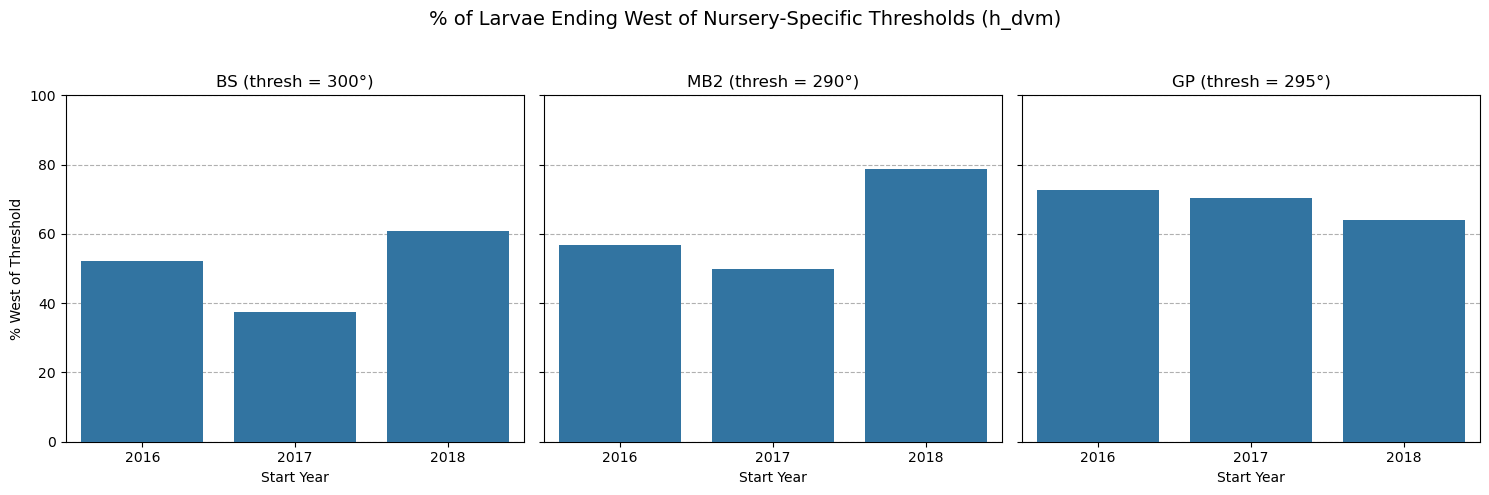

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tag summaries with nursery and lon threshold
bs_summary['nursery'] = 'BS'
bs_summary['lon_thresh'] = 300

gp_summary['nursery'] = 'GP'
gp_summary['lon_thresh'] = 295

mb_summary['nursery'] = 'MB2'
mb_summary['lon_thresh'] = 290

# Combine and filter for h_dvm
summary_all = pd.concat([bs_summary, mb_summary, gp_summary], ignore_index=True)
summary_dvm = summary_all[summary_all['hypothesis'] == 'h_dvm']

# Set up figure with one subplot per nursery
nurseries = summary_dvm['nursery'].unique()
fig, axes = plt.subplots(1, len(nurseries), figsize=(15, 5), sharey=True)

for ax, nursery in zip(axes, nurseries):
    df_n = summary_dvm[summary_dvm['nursery'] == nursery]
    
    # Add gridlines *behind* bars
    ax.grid(True, which='major', axis='y', linestyle='--', zorder=0)

    # Plot bars with zorder above gridlines
    sns.barplot(
        data=df_n,
        x='start_year',
        y='% west',
        ax=ax,
        zorder=3  # ensures bars sit above gridlines
    )
    
    thresh = df_n['lon_thresh'].iloc[0]
    ax.set_title(f'{nursery} (thresh = {thresh}°)')
    ax.set_ylim(0, 100)
    ax.set_xlabel('Start Year')
    ax.set_ylabel('% West of Threshold' if ax == axes[0] else '')

fig.suptitle('% of Larvae Ending West of Nursery-Specific Thresholds (h_dvm)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [125]:
def summarize_nursery_final_lon_bool(df, nursery, lon_threshold=300, debug=False):
    """
    For larvae that used the specified nursery, report how many ended west vs east 
    of the given longitude threshold.

    Returns:
        pd.DataFrame: Counts and percentages of west/east endpoints by year and hypothesis
    """
    if nursery not in df.columns:
        raise ValueError(f"Nursery '{nursery}' not found in DataFrame columns.")

    used_ids = df[df[nursery]]['larval_id'].unique()

    df_last = (
        df[df['larval_id'].isin(used_ids)]
        .sort_values('date')
        .groupby('larval_id', group_keys=False)
        .tail(1)
    )

    if 'lon_360' not in df_last.columns:
        df_last['lon_360'] = df_last['lon'].apply(lambda x: x + 360 if x < 0 else x)

    df_last['is_west'] = df_last['lon_360'] < lon_threshold

    # Aggregate counts
    counts = (
        df_last
        .groupby(['start_year', 'hypothesis', 'is_west'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    # Rename
    counts = counts.rename(columns={True: 'n_west', False: 'n_east'})
    if 'n_west' not in counts.columns:
        counts['n_west'] = 0
    if 'n_east' not in counts.columns:
        counts['n_east'] = 0

    # Add proportions
    counts['n_total'] = counts['n_west'] + counts['n_east']
    counts['% west'] = (counts['n_west'] / counts['n_total']) * 100
    counts['% east'] = (counts['n_east'] / counts['n_total']) * 100

    # Compute std of binary outcomes per group
    std_dev = (
        df_last
        .groupby(['start_year', 'hypothesis'])['is_west']
        .std()
        .reset_index()
        .rename(columns={'is_west': 'std_west_bin'})
    )

    # Convert from proportion std to percentage std
    std_dev['std_west'] = std_dev['std_west_bin'] * 100
    counts = counts.merge(std_dev[['start_year', 'hypothesis', 'std_west']], on=['start_year', 'hypothesis'], how='left')

    if debug:
        from IPython.display import display
        display(df_last[['larval_id', 'lon', 'lon_360', 'is_west']].head())
        display(counts)

    return counts

In [126]:
bs_summary = summarize_nursery_final_lon_bool(merged_raw, nursery='BS', lon_threshold=300)
mb_summary = summarize_nursery_final_lon_bool(merged_raw, nursery='MB2', lon_threshold=290)
gp_summary = summarize_nursery_final_lon_bool(merged_raw, nursery='GP', lon_threshold=295)

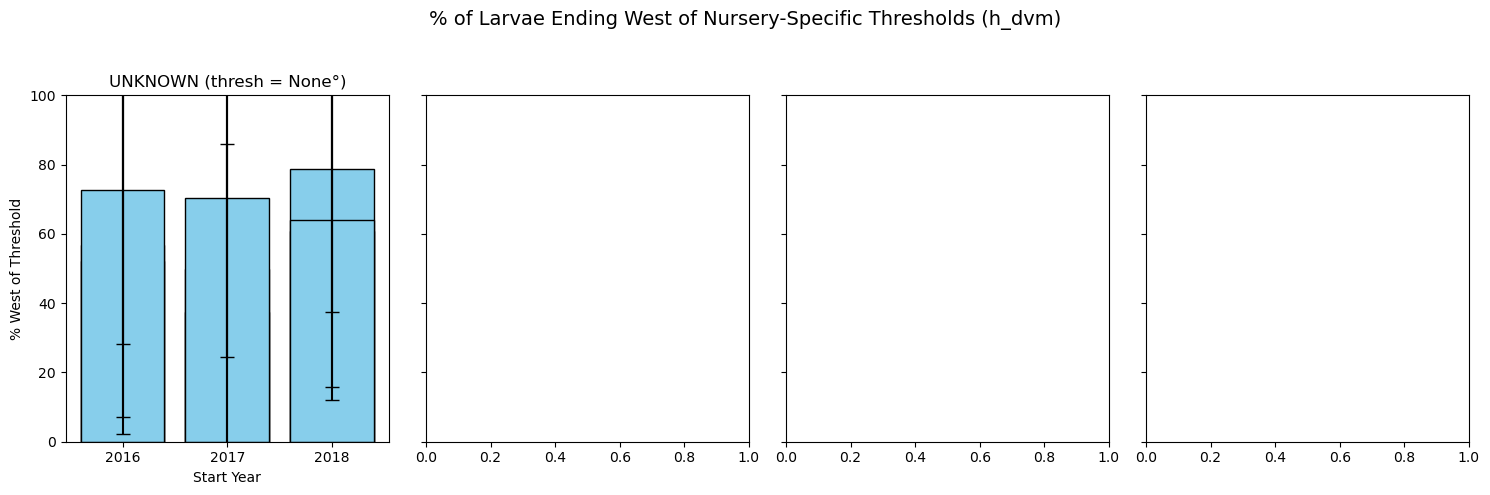

In [127]:
# Combine and filter for h_dvm
for df in [bs_summary, mb_summary, gp_summary]:
    df['nursery'] = df['nursery'] if 'nursery' in df else df['start_year'].map(lambda _: 'UNKNOWN')
    df['lon_thresh'] = df['lon_thresh'] if 'lon_thresh' in df else None

summary_all = pd.concat([bs_summary, mb_summary, gp_summary], ignore_index=True)
summary_dvm = summary_all[summary_all['hypothesis'] == 'h_dvm']

# Plot
fig, axes = plt.subplots(1, len(nurseries), figsize=(15, 5), sharey=True)
for ax, nursery in zip(axes, summary_dvm['nursery'].unique()):
    df_n = summary_dvm[summary_dvm['nursery'] == nursery].copy()
    df_n = df_n.sort_values('start_year')

    ax.bar(
        x=df_n['start_year'].astype(str),
        height=df_n['% west'],
        yerr=df_n['std_west'],
        capsize=5,
        color='skyblue',
        edgecolor='black'
    )
    thresh = df_n['lon_thresh'].iloc[0]
    ax.set_title(f'{nursery} (thresh = {thresh}°)')
    ax.set_ylim(0, 100)
    ax.set_xlabel('Start Year')
    ax.set_ylabel('% West of Threshold' if ax == axes[0] else '')

fig.suptitle('% of Larvae Ending West of Nursery-Specific Thresholds (h_dvm)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()